# Simple Perceptron

Predictions: [0 0 0 1]


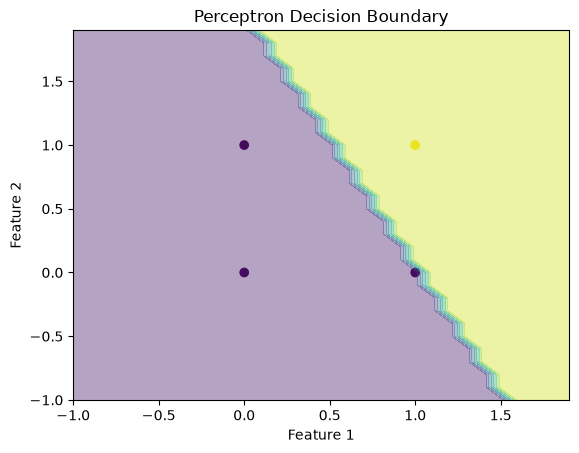

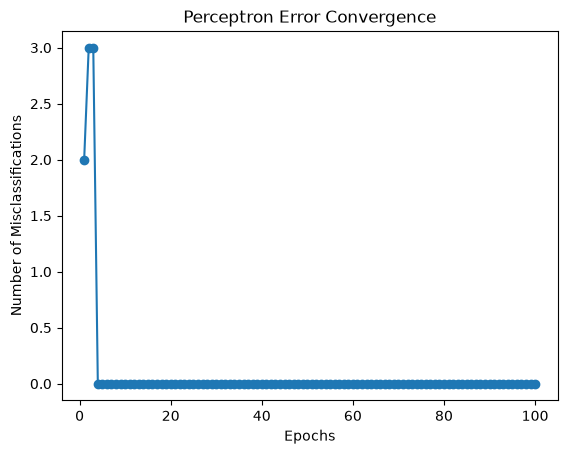

Final weights: [0.2 0.1]
Final bias: -0.20000000000000004


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.errors = []
    
    def fit(self, X, y):
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors = []
        for _ in range(self.n_iters):
            errors = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_function(linear_output)
                # Perceptron update rule
                update = self.learning_rate * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
                errors += int(update != 0.0)
            self.errors.append(errors)
                
    def activation_function(self, x):
        return np.where(x >= 0, 1, 0)
    
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation_function(linear_output)
    
    def plot_decision_boundary(self, X, y):
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
        x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1), np.arange(x2_min, x2_max, 0.1))    
        Z = self.predict(np.c_[xx1.ravel(), xx2.ravel()])
        Z = Z.reshape(xx1.shape)
        plt.contourf(xx1, xx2, Z, alpha=0.4, cmap="viridis")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.title("Perceptron Decision Boundary")
    
# Example data: AND logic gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])  # AND logic output
# y = np.array([0, 1, 1, 1])  # OR logic output
# y = np.array([0, 1, 1, 0])  # XOR logic output


# Create and train Perceptron
perceptron = Perceptron(learning_rate=0.1, n_iters=100)
perceptron.fit(X, y)

# Test the Perceptron
predictions = perceptron.predict(X)
print(f"Predictions: {predictions}")

# Plot decision boundary
perceptron.plot_decision_boundary(X, y)
plt.show()

# Plot error convergence
plt.plot(range(1, len(perceptron.errors) + 1), perceptron.errors, marker="o")
plt.xlabel("Epochs")
plt.ylabel("Number of Misclassifications")
plt.title("Perceptron Error Convergence")
plt.show()

# Print final weights and bias
print(f"Final weights: {perceptron.weights}")
print(f"Final bias: {perceptron.bias}")

# Multilayer Perceptron (MLP)

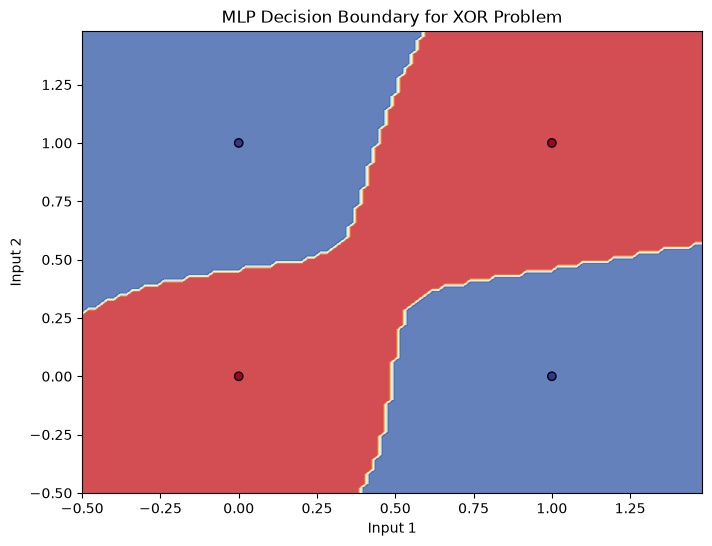

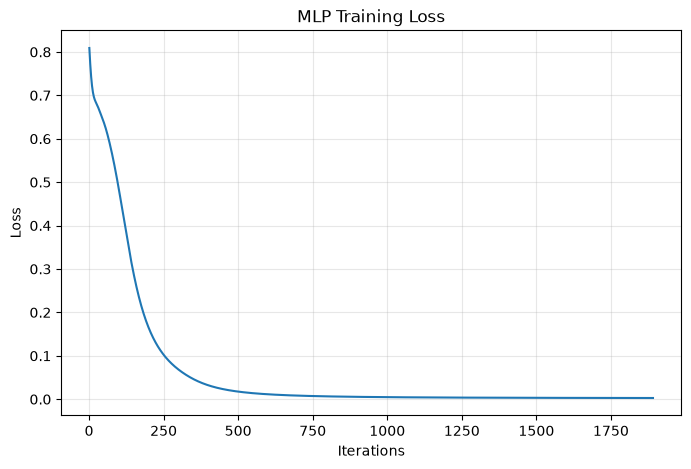

Predictions: [0 1 1 0]
Accuracy: 1.0
Confusion Matrix:
[[2 0]
 [0 2]]
Model Architecture:
Number of layers: 3
Neurons per layer (input, hidden, output): [2, 4, 1]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# XOR dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])  # XOR logic output

# Create MLP classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(4,),
    max_iter=10000,
    activation="tanh",
    solver="adam",
    learning_rate_init=0.01,
    tol=1e-6,
    n_iter_no_change=200,
    random_state=42,
    verbose=False,
)

# Train the MLP
mlp.fit(X, y)

# Make predictions
predictions = mlp.predict(X)

# Calculate accuracy
accuracy = accuracy_score(y, predictions)

# Generate confusion matrix
cm = confusion_matrix(y, predictions)

# Plot decision boundary
def plot_decision_boundary(X, y, model):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors="black")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.title("MLP Decision Boundary for XOR Problem")
    plt.show()

plot_decision_boundary(X, y, mlp)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

# Print results
print(f"Predictions: {predictions}")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(cm)
print("Model Architecture:")
layer_sizes = [X.shape[1], *mlp.hidden_layer_sizes, mlp.n_outputs_]
print(f"Number of layers: {mlp.n_layers_}")
print(f"Neurons per layer (input, hidden, output): {layer_sizes}")

# Gradient descent (GD)

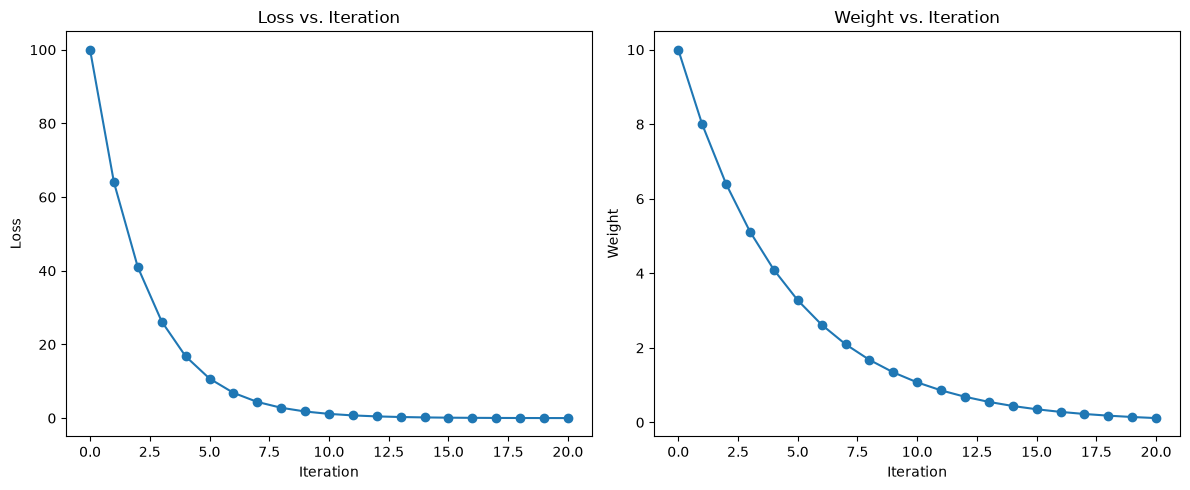

Initial weight: 10.00
Final weight: 0.12
Initial loss: 100.00
Final loss: 0.01


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def loss_function(w):
    """Quadratic loss function: f(w) = w^2"""
    return w**2

def gradient(w):
    """Derivative of the loss function: f'(w) = 2w"""
    return 2 * w

def gradient_descent(initial_w, learning_rate, n_iterations):
    """Perform gradient descent optimization"""
    w = initial_w
    weights = [w]
    losses = [loss_function(w)]
    for i in range(n_iterations):
        grad = gradient(w)
        w = w - learning_rate * grad
        weights.append(w)
        losses.append(loss_function(w))
    return weights, losses

def plot_results(weights, losses):
    """Plot the optimization results"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    # Plot loss curve
    ax1.plot(range(len(losses)), losses, marker='o')
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss vs. Iteration")
    # Plot weight trajectory
    ax2.plot(range(len(weights)), weights, marker='o')
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Weight")
    ax2.set_title("Weight vs. Iteration")
    plt.tight_layout()
    plt.show()
    
# Gradient Descent parameters
initial_w = 10
learning_rate = 0.1
n_iterations = 20

# Perform Gradient Descent
weights, losses = gradient_descent(initial_w, learning_rate, n_iterations)

# Plot results
plot_results(weights, losses)
print(f"Initial weight: {weights[0]:.2f}")
print(f"Final weight: {weights[-1]:.2f}")
print(f"Initial loss: {losses[0]:.2f}")
print(f"Final loss: {losses[-1]:.2f}")

# Momentum optimizer 

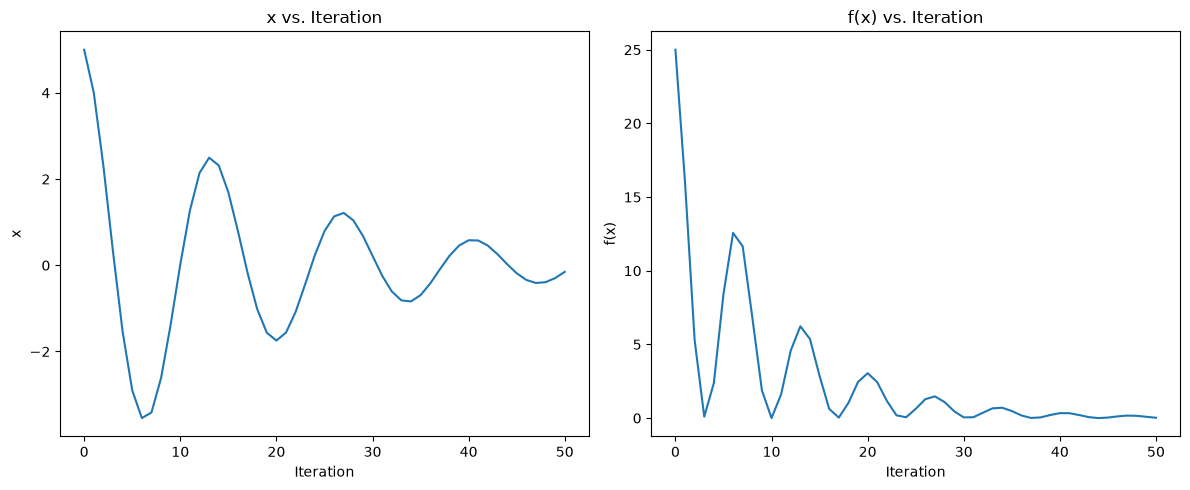

Final x: -0.15249214569569455
Final f(x): 0.023253854498876934


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_function(x):
    return x**2

def quadratic_gradient(x):
    return 2*x

def momentum_optimizer(start_x, learning_rate, momentum, num_iterations):
    x = start_x
    velocity = 0
    x_history, f_history = [x], [quadratic_function(x)]
    for _ in range(num_iterations):
        grad = quadratic_gradient(x)
        velocity = momentum * velocity - learning_rate * grad
        x = x + velocity
        x_history.append(x)
        f_history.append(quadratic_function(x))
    return x, x_history, f_history

# Set hyperparameters
start_x = 5.0
learning_rate = 0.1
momentum = 0.9
num_iterations = 50

# Run momentum optimizer
final_x, x_history, f_history = momentum_optimizer(start_x, learning_rate, momentum, num_iterations)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(num_iterations + 1), x_history)

plt.title("x vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.subplot(1, 2, 2)
plt.plot(range(num_iterations + 1), f_history)
plt.title("f(x) vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.tight_layout()
plt.show()
print(f"Final x: {final_x}")
print(f"Final f(x): {quadratic_function(final_x)}")

# RMSprop optimizer

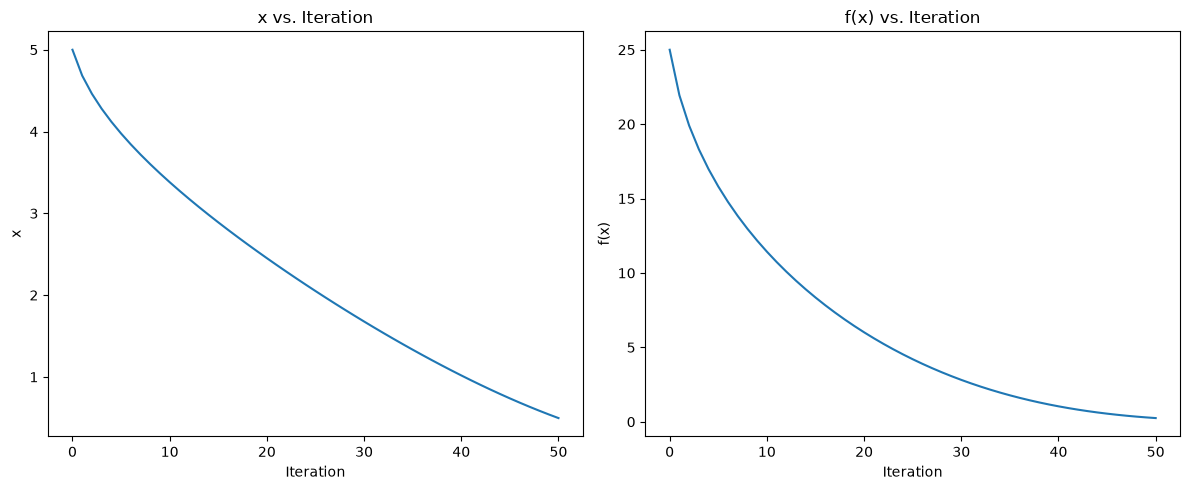

Final x: 0.49652330208741985
Final f(x): 0.24653538951579518


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_function(x):
    return x**2

def quadratic_gradient(x):
    return 2*x

def rmsprop(start_x, learning_rate, beta, num_iterations):
    x = start_x
    x_history, f_history = [x], [quadratic_function(x)]
    v = 0
    epsilon = 1e-8
    for _ in range(num_iterations):
        grad = quadratic_gradient(x)
        v = beta * v + (1 - beta) * (grad**2)
        x = x - learning_rate * grad / (np.sqrt(v) + epsilon)
        x_history.append(x)
        f_history.append(quadratic_function(x))
    return x, x_history, f_history

# Set hyperparameters
start_x = 5.0
learning_rate = 0.1
beta = 0.9
num_iterations = 50

# Run RMSprop
final_x, x_history, f_history = rmsprop(start_x, learning_rate, beta, num_iterations)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(num_iterations + 1), x_history)
plt.title("x vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.subplot(1, 2, 2)
plt.plot(range(num_iterations + 1), f_history)
plt.title("f(x) vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.tight_layout()
plt.show()
print(f"Final x: {final_x}")
print(f"Final f(x): {quadratic_function(final_x)}")

# Adam optimizer

Expected:   [0 1 1 0]
Predicted:  [0 1 1 0]
Training accuracy: 1.00
Training confusion matrix:
[[2 0]
 [0 2]]


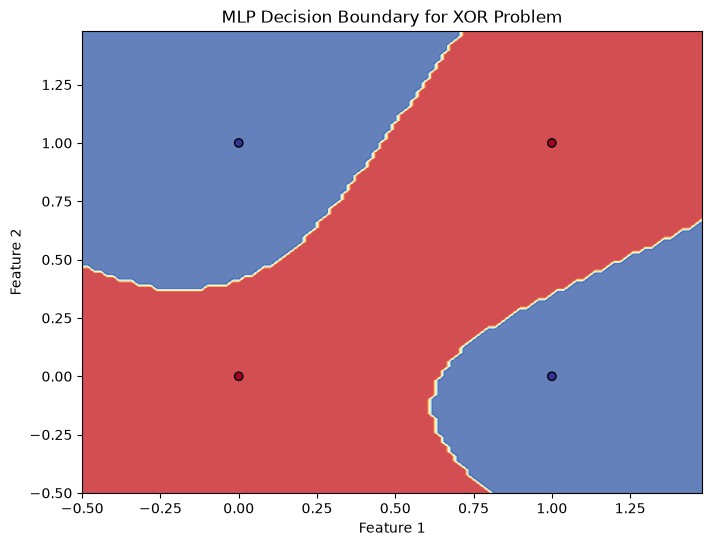

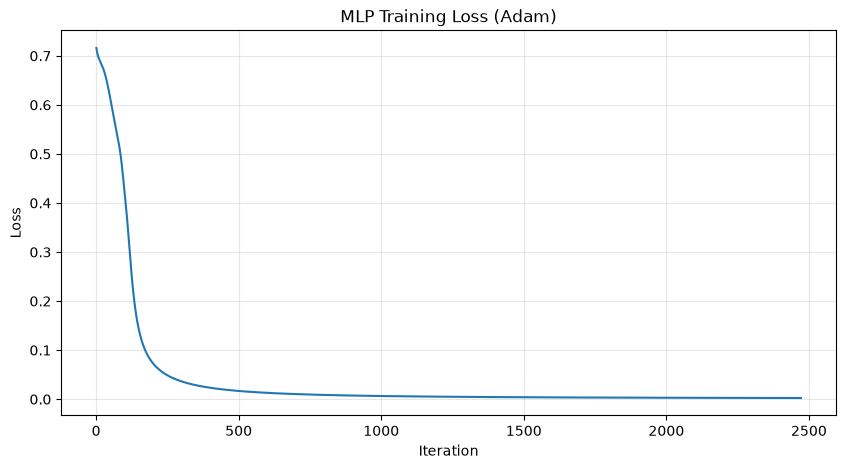

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# XOR truth table
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# Train on all four combinations to demonstrate the XOR truth table.
# This reports training accuracy, not generalization to unseen data.
mlp = MLPClassifier(
    hidden_layer_sizes=(4, 2),
    max_iter=10000,
    solver="adam",
    activation="tanh",
    random_state=42,
    learning_rate_init=0.01,
    tol=1e-6,
    n_iter_no_change=200,
)

mlp.fit(X, y)

# Evaluate the learned XOR truth table
predictions = mlp.predict(X)
accuracy = accuracy_score(y, predictions)
cm = confusion_matrix(y, predictions)

print(f"Expected:   {y}")
print(f"Predicted:  {predictions}")
print(f"Training accuracy: {accuracy:.2f}")
print("Training confusion matrix:")
print(cm)

# Visualize the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor="black")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("MLP Decision Boundary for XOR Problem")
plt.show()

# Plot training loss by iteration
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_)
plt.title("MLP Training Loss (Adam)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()